# 🧱 Part 12: LoRA: Low-Rank Adaptation

> **Previous context**: We have a trainable model, but full fine-tuning can be expensive.
> **Goal for this part**: Implement LoRA, understand low-rank updates, and see how adapters can be merged for inference.

Today we are solving one concrete confusion: what is the hidden mechanism behind this part of an LLM, and how can we rebuild it with small numbers before trusting a library?

## 0. Why LoRA exists

A pretrained model already stores broad knowledge. For a new task, we often only need a small update rather than changing every weight.

## 1. Low-rank idea

Instead of learning a full weight update matrix, LoRA learns two smaller matrices A and B whose product approximates the update.

## 2. Where to apply it

LoRA is commonly attached to attention projections or other linear layers where small targeted changes are useful.

## 3. Merge for inference

After training, the low-rank update can be folded into the base weight so inference stays simple.

## How to use the code cells

Run the cells in order. The code is intentionally direct and small: each cell should expose one idea, print the key observation, and let you change a number to see what moves.

## Exercises

When a cell contains a TODO placeholder, fill it yourself and use the `assert` checks as feedback. You can ask an AI for hints, step-by-step reasoning, or a direction check, but avoid asking it to complete the exercise outright.

## Summary Checklist

- [ ] LoRA freezes the base weight and learns a low-rank update.
- [ ] A and B are much smaller than a full update matrix.
- [ ] LoRA can often be merged into the base model for inference.

Next, continue through the code cells for the Training Systems part and inspect the printed observations.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

In [2]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
torch.manual_seed(42)

d_in, d_out, r = 4, 4, 2
alpha = 2  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
W = torch.randn(d_out, d_in)
print('Read the values printed above and connect them to the concept in this cell.')
print(W)
print(f"Read the values printed above and connect them to the concept in this cell.{W.numel()}")

# Teaching note: follow this line to see the main step.
A = torch.randn(d_out, r) * 0.02   # Teaching note: follow this line to see the main step.
B = torch.zeros(r, d_in)            # Teaching note: follow this line to see the main step.
print(f"\nA (d_out x r = 4x2):")
print(A)
print(f"Read the values printed above and connect them to the concept in this cell.")
print(B)
print(f"Read the values printed above and connect them to the concept in this cell.{A.numel()}Read the values printed above and connect them to the concept in this cell.{B.numel()}Read the values printed above and connect them to the concept in this cell.{A.numel() + B.numel()}")
print(f"Read the values printed above and connect them to the concept in this cell.{W.numel() / (A.numel() + B.numel()):.1f}x")

# Teaching note: follow this line to see the main step.
x = torch.tensor([1.0, 0.5, -0.5, -1.0])
print(f"\nInput x (4,): {x}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
# Teaching note: follow this line to see the main step.
h_original = W @ x
print(f"Read the values printed above and connect them to the concept in this cell.{h_original}")

# Teaching note: follow this line to see the main step.
h_lora = B @ x     # Teaching note: follow this line to see the main step.
h_lora = A @ h_lora  # Teaching note: follow this line to see the main step.
scaling = alpha / r
delta = h_lora * scaling
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"  Step 1 - Bx (r={r},): {h_lora}")
print(f"  Step 2 - A(Bx) (d_out={d_out},): {h_lora}")
print(f"Read the values printed above and connect them to the concept in this cell.{scaling}")
print(f"  delta = (alpha/r) * A(Bx): {delta}")

# Teaching note: follow this line to see the main step.
h_final = h_original + delta
print(f"Read the values printed above and connect them to the concept in this cell.{h_final}")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.{(h_final == h_original).all().item()}")
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624]])
Read the values printed above and connect them to the concept in this cell.
A (d_out x r = 4x2):
tensor([[ 0.0092,  0.0053],
        [ 0.0107,  0.0162],
        [ 0.0222, -0.0338],
        [-0.0198,  0.0192]])
Read the values printed above and connect them to the concept in this cell.tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Input x (4,): tensor([ 1.0000, 0.5000, -0.5000, -1.0000])
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  Step 1 - Bx (r=2,): tensor([0., 0., 0., 

In [3]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
class LoraLinear(nn.Module):
    'Read the values printed above and connect them to the concept in this cell.'
    def __init__(self, linear: nn.Linear, r: int, alpha: int = None):
        super().__init__()
        # Teaching note: follow this line to see the main step.
        self.linear = linear
        self.in_features = linear.in_features
        self.out_features = linear.out_features
        self.r = r
        self.alpha = alpha if alpha is not None else r

        # Teaching note: follow this line to see the main step.
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        # Teaching note: follow this line to see the main step.
        # A: (out_features, r)  B: (r, in_features)
        self.lora_A = nn.Parameter(torch.randn(self.out_features, r) * 0.02)
        self.lora_B = nn.Parameter(torch.zeros(r, self.in_features))
        self.scaling = self.alpha / self.r

    def forward(self, x):
        # Teaching note: follow this line to see the main step.
        original = self.linear(x)  # x @ W^T + bias
        # Teaching note: follow this line to see the main step.
        # Teaching note: follow this line to see the main step.
        # Teaching note: follow this line to see the main step.
        lora_out = (x @ self.lora_B.T) @ self.lora_A.T * self.scaling
        return original + lora_out

    @property
    def weight(self):
        'Read the values printed above and connect them to the concept in this cell.'
        with torch.no_grad():
            delta_W = self.lora_A @ self.lora_B * self.scaling
            return self.linear.weight + delta_W


# Teaching note: follow this line to see the main step.
torch.manual_seed(42)
linear = nn.Linear(4, 4, bias=False)
linear.weight.data = torch.randn(4, 4)  # Teaching note: follow this line to see the main step.

lora_layer = LoraLinear(linear, r=2, alpha=2)

print('Read the values printed above and connect them to the concept in this cell.')
print(f"Read the values printed above and connect them to the concept in this cell.{lora_layer.linear.weight.requires_grad}")
print(f"  lora_A requires_grad: {lora_layer.lora_A.requires_grad}")
print(f"  lora_B requires_grad: {lora_layer.lora_B.requires_grad}")

# Teaching note: follow this line to see the main step.
total = sum(p.numel() for p in lora_layer.parameters())
trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
print(f"Read the values printed above and connect them to the concept in this cell.{total}Read the values printed above and connect them to the concept in this cell.{trainable} ({100*trainable/total:.1f}%)")

# Teaching note: follow this line to see the main step.
x = torch.tensor([[1.0, 0.5, -0.5, -1.0]])
y = lora_layer(x)
print(f"\n  Input x: {x.tolist()}")
print(f"  Output y: {y.tolist()}")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.  lora_A requires_grad: True
  lora_B requires_grad: True

Read the values printed above and connect them to the concept in this cell.
Input x: [[1.0, 0.5, -0.5, -1.0]]Output y: [[1.3716278076171875, -2.2999930381774902, 0.28736478090286255, -0.944815456867218]]

In [4]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
torch.manual_seed(42)

# Teaching note: follow this line to see the main step.
d = 4
W_target = torch.tensor([
    [ 0.5, -0.3,  0.8, -0.2],
    [-0.4,  0.6, -0.1,  0.7],
    [ 0.3, -0.5, -0.6,  0.4],
    [-0.7,  0.2,  0.5, -0.8],
])

N = 30
X_train = torch.randn(N, d)
y_train = X_train @ W_target + 0.05 * torch.randn(N, d)  # Teaching note: follow this line to see the main step.

print(f"trainingdata: X ({N}x{d}), y ({N}x{d})")
print(f"Read the values printed above and connect them to the concept in this cell.{W_target}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
torch.manual_seed(100)
W_full = nn.Linear(d, d, bias=False)
W_full.weight.data = torch.randn(d, d)  # Teaching note: follow this line to see the main step.

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{W_full.weight.data}")
print(f"Read the values printed above and connect them to the concept in this cell.{sum(p.numel() for p in W_full.parameters())}")

opt_full = torch.optim.Adam(W_full.parameters(), lr=0.01)
losses_full = []
for epoch in range(200):
    opt_full.zero_grad()
    loss = F.mse_loss(W_full(X_train), y_train)
    loss.backward()
    opt_full.step()
    losses_full.append(loss.item())

print(f"Loss{losses_full[-1]:.6f}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
torch.manual_seed(100)  # Teaching note: follow this line to see the main step.
W_base = nn.Linear(d, d, bias=False)
W_base.weight.data = torch.randn(d, d)  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
lora_model = LoraLinear(W_base, r=2, alpha=4)

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{lora_model.linear.weight.data}")
print(f"Read the values printed above and connect them to the concept in this cell.{sum(p.numel() for p in lora_model.parameters() if p.requires_grad)}")

opt_lora = torch.optim.Adam(lora_model.parameters(), lr=0.01)
losses_lora = []
for epoch in range(200):
    opt_lora.zero_grad()
    loss = F.mse_loss(lora_model(X_train), y_train)
    loss.backward()
    opt_lora.step()
    losses_lora.append(loss.item())

print(f"Loss{losses_lora[-1]:.6f}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Loss{losses_full[-1]:.6f}Read the values printed above and connect them to the concept in this cell.{d*d}Read the values printed above and connect them to the concept in this cell.")
print(f"  LoRA r=2  loss: {losses_lora[-1]:.6f}Read the values printed above and connect them to the concept in this cell.{2*d*2}Read the values printed above and connect them to the concept in this cell.")

# Teaching note: follow this line to see the main step.
with torch.no_grad():
    learned_W = lora_model.weight  # Teaching note: follow this line to see the main step.
    print(f"Read the values printed above and connect them to the concept in this cell.{learned_W}")
    print(f"Read the values printed above and connect them to the concept in this cell.{W_target}")
    print(f"Read the values printed above and connect them to the concept in this cell.{F.mse_loss(learned_W, W_target):.6f}")

    full_W = W_full.weight.data
    print(f"Read the values printed above and connect them to the concept in this cell.{F.mse_loss(full_W, W_target):.6f}")

trainingdata: X (30x4), y (30x4)Read the values printed above and connect them to the concept in this cell.tensor([[ 0.5000, -0.3000,  0.8000, -0.2000],
        [-0.4000,  0.6000, -0.1000,  0.7000],
        [ 0.3000, -0.5000, -0.6000,  0.4000],
        [-0.7000,  0.2000,  0.5000, -0.8000]])

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.tensor([[-3.1896,  1.5914, -0.0247, -0.8466],
        [ 0.0293, -0.5721, -1.2546,  0.0486],
        [ 1.1705, -0.5410, -0.7116,  0.0575],
        [ 0.6263, -1.7736, -0.2205,  2.7467]])
Read the values printed above and connect them to the concept in this cell.

Loss
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.tensor([[-3.1896,  1.5914, -0.0247, -0.8466],
        [ 0.0293, -0.5721, -1.2546,  0.0486],
        [ 1.1705, -0.5410, -0.7116,  0.0575],
        [ 0.6263, -1.7736, -0.2205,  2.7467]])
Read the values printed above and connect them to the concept in this cell.Loss
Read the values printed above and connect them to the concept in this cell.LossLoss
Read the values printed above and connect them to the concept in this cell.tensor([[ 0.4577, -0.5376,  0.1780, -0.7993],
        [-0.5185, -0.0261, -1.2047, -0.3421],
        [ 0.6740, -0.3800, -0.7849,  0.2696],
        [-0.1851,  0.7563,  0.4649, -0.7511]])
Read the values printed above and connect them to the concept in this cell.tensor([[ 0.5000, -0.3000,  0.8000, -0.2000],
        [-0.4000,  0.6000, -0.1000,  0.7000],
        [ 0.3000, -0.5000, -0.6000,  0.4000],
        [-0.7000,  0.20

In [5]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_O(out)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = x + self.attention(self.norm1(x), mask)
        x = x + self.ffn(self.norm2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, max_len=128):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.register_buffer('pos_encoding', get_sinusoidal_encoding(max_len, d_model))
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        B, S = x.shape
        x_emb = self.token_embedding(x) + self.pos_encoding[:S, :]
        for block in self.blocks:
            x_emb = block(x_emb, mask)
        x_emb = self.norm_final(x_emb)
        return self.lm_head(x_emb)

# Teaching note: follow this line to see the main step.
def causal_mask(seq_len):
    return torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)

print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.

In [6]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
def apply_lora_to_attention(model, r=16, alpha=32):
    'Read the values printed above and connect them to the concept in this cell.'
    lora_params = 0
    for block in model.blocks:
        attn = block.attention
        # Teaching note: follow this line to see the main step.
        attn.W_Q = LoraLinear(attn.W_Q, r=r, alpha=alpha)
        # Teaching note: follow this line to see the main step.
        attn.W_V = LoraLinear(attn.W_V, r=r, alpha=alpha)
        # Teaching note: follow this line to see the main step.
        lora_params += attn.W_Q.lora_A.numel() + attn.W_Q.lora_B.numel()
        lora_params += attn.W_V.lora_A.numel() + attn.W_V.lora_B.numel()
    return lora_params

VOCAB_SIZE = 50
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)

# Teaching note: follow this line to see the main step.
total_params = sum(p.numel() for p in model.parameters())
print(f"Read the values printed above and connect them to the concept in this cell.{total_params:,}")

# Teaching note: follow this line to see the main step.
lora_params = apply_lora_to_attention(model, r=8, alpha=16)

# Teaching note: follow this line to see the main step.
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{frozen_params:,} ({100*frozen_params/total_params:.1f}%)")
print(f"Read the values printed above and connect them to the concept in this cell.{trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"Read the values printed above and connect them to the concept in this cell.{100*trainable_params/total_params:.2f}Read the values printed above and connect them to the concept in this cell.")

# Teaching note: follow this line to see the main step.
for name, param in model.named_parameters():
    if 'lora' not in name and 'lm_head' not in name and 'token_embedding' not in name:
        if param.requires_grad:
            print(f"  WARNING: {name} should be frozen but requires_grad=True")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.  WARNING: blocks.0.attention.W_K.weight should be frozen but requires_grad=True

Read the values printed above and connect them to the concept in this cell.

In [7]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
word_to_id = {
    "BOS": 0, "EOS": 1,
    '"hello"': 2, '"thanks"': 3, '"goodbye"': 4, '"today"': 5, '"weather"': 6, '"nice"': 7,
    'Read the values printed above and connect them to the concept in this cell.': 8, 'Read the values printed above and connect them to the concept in this cell.': 9, 'Read the values printed above and connect them to the concept in this cell.': 10, 'Read the values printed above and connect them to the concept in this cell.': 11, '"assistant"': 12, "AI": 13,
    'Read the values printed above and connect them to the concept in this cell.': 14, '"Why"': 15, '"How"': 16, 'Read the values printed above and connect them to the concept in this cell.': 17, '"can"': 18,
    'Read the values printed above and connect them to the concept in this cell.': 19, 'Read the values printed above and connect them to the concept in this cell.': 20, '"like"': 21, '"dislike"': 22, '"know"': 23, '"do not know"': 24,
    '"math"': 25, '"English"': 26, '"programming"': 27, 'Read the values printed above and connect them to the concept in this cell.': 28, '"code"': 29,
    '"today"': 5, '"weekday"': 30, 'Read the values printed above and connect them to the concept in this cell.': 31, 'Read the values printed above and connect them to the concept in this cell.': 32, 'Read the values printed above and connect them to the concept in this cell.': 33,
}

# Teaching note: follow this line to see the main step.
word_to_id = {
    "BOS": 0, "EOS": 1, "PAD": 0,
    '"hello"': 2, '"thanks"': 3, '"goodbye"': 4, '"today"': 5, '"weather"': 6, '"nice"': 7,
    'Read the values printed above and connect them to the concept in this cell.': 8, 'Read the values printed above and connect them to the concept in this cell.': 9, 'Read the values printed above and connect them to the concept in this cell.': 10, 'Read the values printed above and connect them to the concept in this cell.': 11, '"assistant"': 12, "AI": 13,
    'Read the values printed above and connect them to the concept in this cell.': 14, '"Why"': 15, '"How"': 16, 'Read the values printed above and connect them to the concept in this cell.': 17, '"can"': 18,
    'Read the values printed above and connect them to the concept in this cell.': 19, 'Read the values printed above and connect them to the concept in this cell.': 20, '"like"': 21, '"dislike"': 22, '"know"': 23, '"do not know"': 24,
    '"math"': 25, '"English"': 26, '"programming"': 27, 'Read the values printed above and connect them to the concept in this cell.': 28, '"code"': 29,
    '"weekday"': 30, 'Read the values printed above and connect them to the concept in this cell.': 31, 'Read the values printed above and connect them to the concept in this cell.': 32, 'Read the values printed above and connect them to the concept in this cell.': 33, 'Read the values printed above and connect them to the concept in this cell.': 34,
    'Read the values printed above and connect them to the concept in this cell.': 35, 'Read the values printed above and connect them to the concept in this cell.': 36, 'Read the values printed above and connect them to the concept in this cell.': 37, 'Read the values printed above and connect them to the concept in this cell.': 38, 'Read the values printed above and connect them to the concept in this cell.': 39,
    'Read the values printed above and connect them to the concept in this cell.': 40, 'Read the values printed above and connect them to the concept in this cell.': 41, 'Read the values printed above and connect them to the concept in this cell.': 42, 'Read the values printed above and connect them to the concept in this cell.': 43, 'Read the values printed above and connect them to the concept in this cell.': 44,
    'Read the values printed above and connect them to the concept in this cell.': 45, 'Read the values printed above and connect them to the concept in this cell.': 46, 'Read the values printed above and connect them to the concept in this cell.': 47, 'Read the values printed above and connect them to the concept in this cell.': 48, 'Read the values printed above and connect them to the concept in this cell.': 49,
}

# Teaching note: follow this line to see the main step.
conversations = [
    ('"hello"', 'Read the values printed above and connect them to the concept in this cell.'),
    ('"todayweathernice"', 'Read the values printed above and connect them to the concept in this cell.'),
    ('Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.'),
    ('Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.'),
    ('"thanks"', 'Read the values printed above and connect them to the concept in this cell.'),
    ('"goodbye"', 'Read the values printed above and connect them to the concept in this cell.'),
]

def encode_text(text):
    'Read the values printed above and connect them to the concept in this cell.'
    ids = []
    for word in text:
        if word in word_to_id:
            ids.append(word_to_id[word])
        else:
            ids.append(0)  # Teaching note: follow this line to see the main step.
    return ids

print('Read the values printed above and connect them to the concept in this cell.')
for q, a in conversations[:3]:
    print(f"  User: {q}  →  Assistant: {a}")
    q_ids = encode_text(q)
    a_ids = encode_text(a)
    print(f"    IDs: User {q_ids}, Assistant {a_ids}")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.    IDs: User [8, 19], Assistant [8, 19, 0, 0, 0, 0, 0, 0, 0, 8, 39, 38, 0]
Read the values printed above and connect them to the concept in this cell.    IDs: User [0, 37, 37, 0, 41, 43], Assistant [9, 39, 0, 0, 37, 37, 0, 40, 19, 0, 0, 0, 0, 0, 0, 0]
Read the values printed above and connect them to the concept in this cell.    IDs: User [8, 9, 10], Assistant [11, 9, 31, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 39, 0, 0, 0]


In [8]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
VOCAB_SIZE = 50
SEQ_LEN = 24
torch.manual_seed(42)

# Teaching note: follow this line to see the main step.
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2, max_len=SEQ_LEN)
apply_lora_to_attention(model, r=8, alpha=16)

# Teaching note: follow this line to see the main step.
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.001
)

print(f"Read the values printed above and connect them to the concept in this cell.{sum(p.numel() for p in optimizer.param_groups[0]['params']):,}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
NUM_EPOCHS = 50
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0

    for user_text, assistant_text in conversations:
        # Teaching note: follow this line to see the main step.
        user_ids = encode_text(user_text)
        asst_ids = encode_text(assistant_text)
        full_seq = [word_to_id["BOS"]] + user_ids + asst_ids + [word_to_id["EOS"]]

        # Teaching note: follow this line to see the main step.
        if len(full_seq) > SEQ_LEN:
            full_seq = full_seq[:SEQ_LEN]
        input_ids = torch.tensor([full_seq + [0] * (SEQ_LEN - len(full_seq))])

        # Teaching note: follow this line to see the main step.
        mask = causal_mask(SEQ_LEN)
        logits = model(input_ids, mask)  # (1, S, V)

        # Teaching note: follow this line to see the main step.
        labels = torch.cat([input_ids[:, 1:], torch.zeros(1, 1, dtype=torch.long)], dim=1)

        # Teaching note: follow this line to see the main step.
        loss = F.cross_entropy(
            logits.view(-1, VOCAB_SIZE),
            labels.view(-1),
            ignore_index=0  # PAD
        )

        epoch_loss += loss.item()

        # Teaching note: follow this line to see the main step.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(conversations)
    losses.append(avg_loss)

    if epoch % 5 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

print(f"Loss{losses[0]:.4f}Loss{losses[-1]:.4f}")
print(f"Loss{losses[0] - losses[-1]:.4f}")

Read the values printed above and connect them to the concept in this cell.Epoch   0 | Loss: 3.7294
Epoch   5 | Loss: 1.7626
Epoch  10 | Loss: 0.8616


Epoch  15 | Loss: 0.3865
Epoch  20 | Loss: 0.2258
Epoch  25 | Loss: 0.1584
Epoch  30 | Loss: 0.1314


Epoch  35 | Loss: 0.1117
Epoch  40 | Loss: 0.1021
Epoch  45 | Loss: 0.0958
Epoch  49 | Loss: 0.0922

LossLoss

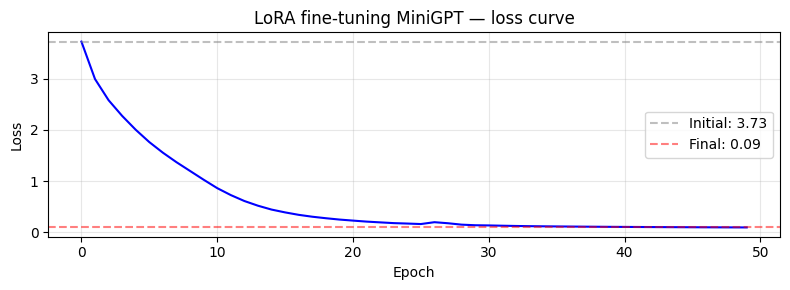


ConclusionRead the values printed above and connect them to the concept in this cell.

In [9]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(losses, 'b-', linewidth=1.5)
plt.axhline(y=losses[0], color='gray', linestyle='--', alpha=0.5, label=f'Initial: {losses[0]:.2f}')
plt.axhline(y=losses[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.2f}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LoRA fine-tuning MiniGPT — loss curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Conclusion')
print('Read the values printed above and connect them to the concept in this cell.')


In [10]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
def merge_lora(model):
    'Read the values printed above and connect them to the concept in this cell.'
    for block in model.blocks:
        attn = block.attention
        for name in ['W_Q', 'W_V']:
            layer = getattr(attn, name)
            if isinstance(layer, LoraLinear):
                # Teaching note: follow this line to see the main step.
                merged_weight = layer.linear.weight.data + layer.lora_A.data @ layer.lora_B.data * layer.scaling
                # Teaching note: follow this line to see the main step.
                new_linear = nn.Linear(layer.in_features, layer.out_features, bias=False)
                new_linear.weight.data = merged_weight
                setattr(attn, name, new_linear)

# Teaching note: follow this line to see the main step.
trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Read the values printed above and connect them to the concept in this cell.{trainable_before}")

merge_lora(model)

trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Read the values printed above and connect them to the concept in this cell.{trainable_after}")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [ ]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================

# Teaching note: follow this line to see the main step.
params_7B = 7e9

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
num_layers = 32
d_model = 4096
lora_r = 16
lora_params_per_layer = 2 * (d_model * lora_r + lora_r * d_model)  # Teaching note: follow this line to see the main step.
total_lora_params = num_layers * lora_params_per_layer

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{params_7B/1e9:.0f}B")
print(f"Read the values printed above and connect them to the concept in this cell.{total_lora_params:,} ({total_lora_params/params_7B*100:.2f}%)")
print()

# Teaching note: follow this line to see the main step.
model_fp16 = params_7B * 2 / 1e9       # 2 bytes per param
optimizer_adam = params_7B * 12 / 1e9   # Adam: 12 bytes per param (momentum + variance + master weights)
gradients = params_7B * 2 / 1e9          # 2 bytes per param
activations = 8  # Teaching note: follow this line to see the main step.
full_total = model_fp16 + optimizer_adam + gradients + activations

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{model_fp16:.0f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{optimizer_adam:.0f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{gradients:.0f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{activations} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{full_total:.0f} GB")
print()

# 2) LoRA
# Teaching note: follow this line to see the main step.
lora_model = model_fp16
lora_optim = total_lora_params * 12 / 1e9
lora_grad = total_lora_params * 2 / 1e9
lora_total = lora_model + lora_optim + lora_grad + activations

print(f"--- LoRA (r={lora_r}) ---")
print(f"Read the values printed above and connect them to the concept in this cell.{lora_model:.0f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{lora_optim:.2f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{lora_grad:.3f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{activations} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{lora_total:.0f} GB")
print()

# 3) QLoRA
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
qlora_model = params_7B * 0.5 / 1e9  # 4-bit = 0.5 byte per param
qlora_optim = lora_optim
qlora_grad = lora_grad
qlora_double_quant = 0.4  # Teaching note: follow this line to see the main step.
qlora_total = qlora_model + qlora_optim + qlora_grad + activations + qlora_double_quant

print(f"--- QLoRA (r={lora_r}, NF4) ---")
print(f"Read the values printed above and connect them to the concept in this cell.{qlora_model:.1f} GB")
print(f"  Double Quantization:   +{qlora_double_quant}Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{qlora_optim:.2f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{qlora_grad:.3f} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{activations} GB")
print(f"Read the values printed above and connect them to the concept in this cell.{qlora_total:.0f} GB")
print()

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{full_total:.0f}Read the values printed above and connect them to the concept in this cell.{lora_total:.0f} GB ({full_total/lora_total:.1f}x)")
print(f"Read the values printed above and connect them to the concept in this cell.{lora_total:.0f}Read the values printed above and connect them to the concept in this cell.{qlora_total:.0f} GB ({lora_total/qlora_total:.1f}x)")
print(f"Read the values printed above and connect them to the concept in this cell.{full_total:.0f}Read the values printed above and connect them to the concept in this cell.{qlora_total:.0f} GB ({full_total/qlora_total:.1f}x)")
print()
print('Key observation: inspect the values above and connect them to the idea in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')


In [ ]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================

import numpy as np

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
nf4_levels = np.array([
    -1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.1880, -0.0950,  0.0,
     0.0594,  0.1524,  0.2500,  0.3536,  0.4714,  0.6107,  0.7906,  1.0
])

print('Read the values printed above and connect them to the concept in this cell.')
print(f"Read the values printed above and connect them to the concept in this cell.{nf4_levels[:8].tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{nf4_levels[8:].tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
print()

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
absmax = 0.8

# Teaching note: follow this line to see the main step.
weights_fp16 = np.array([0.12, -0.35, 0.67, -0.02, 0.51])

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{absmax}")
print(f"Read the values printed above and connect them to the concept in this cell.{weights_fp16.tolist()}")
print()

# Teaching note: follow this line to see the main step.
weights_norm = weights_fp16 / absmax
print(f"Read the values printed above and connect them to the concept in this cell.{[f'{v:.4f}' for v in weights_norm]}")

# Teaching note: follow this line to see the main step.
quant_indices = []
quant_values = []
for w in weights_norm:
    # Teaching note: follow this line to see the main step.
    idx = np.argmin(np.abs(nf4_levels - w))
    quant_indices.append(idx)
    quant_values.append(nf4_levels[idx])

quant_indices = np.array(quant_indices)
quant_values = np.array(quant_values)

print(f"Read the values printed above and connect them to the concept in this cell.{quant_indices.tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{[f'{v:.4f}' for v in quant_values]}")
print(f"Read the values printed above and connect them to the concept in this cell.")
print()

# Teaching note: follow this line to see the main step.
weights_dequant = quant_values * absmax
print(f"Read the values printed above and connect them to the concept in this cell.{[f'{v:.4f}' for v in weights_dequant]}")
print()

# Teaching note: follow this line to see the main step.
error = weights_fp16 - weights_dequant
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{[f'{v:7.4f}' for v in weights_fp16]}")
print(f"Read the values printed above and connect them to the concept in this cell.{[f'{v:7.4f}' for v in weights_dequant]}")
print(f"Read the values printed above and connect them to the concept in this cell.{[f'{v:7.4f}' for v in error]}")
print(f"Read the values printed above and connect them to the concept in this cell.{np.max(np.abs(error)):.4f}")
print(f"Read the values printed above and connect them to the concept in this cell.{np.max(np.abs(error)) / np.max(np.abs(weights_fp16)) * 100:.1f}%")
print()
print('Key observation: inspect the values above and connect them to the idea in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print(f"Read the values printed above and connect them to the concept in this cell.")


Read the values printed above and connect them to the concept in this cell.
1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Read the values printed above and connect them to the concept in this cell.4. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## Summary
- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Loss- Read the values printed above and connect them to the concept in this cell.